# Urban Flood Risk Prediction Using Machine Learning Techniques

## Course Project

### Objective
The objective of this project is to predict urban flood risk using environmental, topographic, and drainage-related variables. Different machine learning classification algorithms will be compared to identify the most effective model and the most influential flood risk factors.

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. Load Dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving urban_pluvial_flood_risk_dataset.csv to urban_pluvial_flood_risk_dataset.csv


In [5]:
df = pd.read_csv("urban_pluvial_flood_risk_dataset.csv")

df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


# 3. Data Exploration

In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(2963, 17)

Data Types:
segment_id                              object
city_name                               object
admin_ward                              object
latitude                               float64
longitude                              float64
catchment_id                            object
elevation_m                            float64
dem_source                              object
land_use                                object
soil_group                              object
drainage_density_km_per_km2            float64
storm_drain_proximity_m                float64
storm_drain_type                        object
rainfall_source                         object
historical_rainfall_intensity_mm_hr    float64
return_period_years                      int64
risk_labels                             object
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   object 
 1   city_name                            2963 non-null   object 
 2   admin_ward                           2963 non-null   object 
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   object 
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   object 
 8   land_use                             2963 non-null   object 
 9   soil_group                           2601 non-null   object 
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_drain_proximity_m       

## 3.1 Descriptive Statistics

In [8]:
df.describe()

,latitude,longitude,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years
count,2963.000000,2963.000000,2802.000000,2679.000000,2724.000000,2963.000000,2963.000000
mean,19.399103,31.676123,37.689818,6.290866,123.202203,43.811441,19.730003
std,24.446320,79.542482,38.708958,2.187365,107.764541,25.221200,25.182883
min,-36.999038,-123.292949,-3.000000,1.270000,0.200000,5.400000,2.000000
25%,6.580006,-43.124581,8.725000,4.670000,47.975000,25.800000,5.000000
50%,23.760802,36.889173,25.130000,6.250000,91.700000,37.900000,10.000000
75%,37.887422,101.701136,59.620000,7.830000,162.625000,55.550000,25.000000
max,55.821219,174.911271,266.700000,12.070000,751.700000,150.000000,100.000000


In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
latitude,2963.0,19.399103,24.446320,-36.999038,6.580006,23.760802,37.887422,55.821219
longitude,2963.0,31.676123,79.542482,-123.292949,-43.124581,36.889173,101.701136,174.911271
elevation_m,2802.0,37.689818,38.708958,-3.000000,8.725000,25.130000,59.620000,266.700000
drainage_density_km_per_km2,2679.0,6.290866,2.187365,1.270000,4.670000,6.250000,7.830000,12.070000
storm_drain_proximity_m,2724.0,123.202203,107.764541,0.200000,47.975000,91.700000,162.625000,751.700000
historical_rainfall_intensity_mm_hr,2963.0,43.811441,25.221200,5.400000,25.800000,37.900000,55.550000,150.000000
return_period_years,2963.0,19.730003,25.182883,2.000000,5.000000,10.000000,25.000000,100.000000


##3.2 Numerical Feature Distributions

In [10]:
numeric_features = [
    "elevation_m",
    "drainage_density_km_per_km2",
    "storm_drain_proximity_m",
    "historical_rainfall_intensity_mm_hr",
    "return_period_years"
]

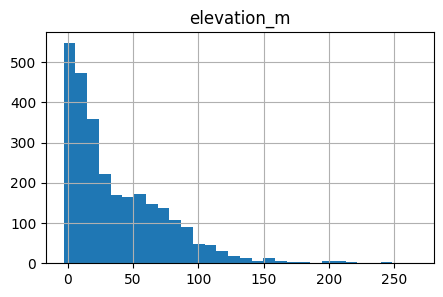

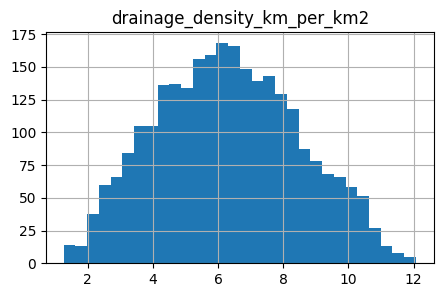

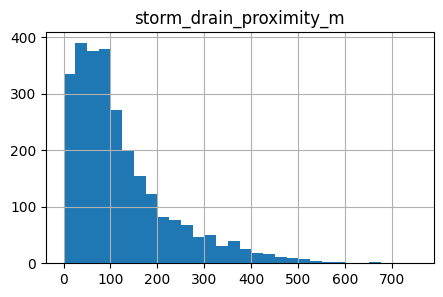

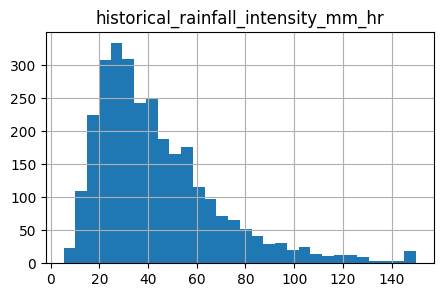

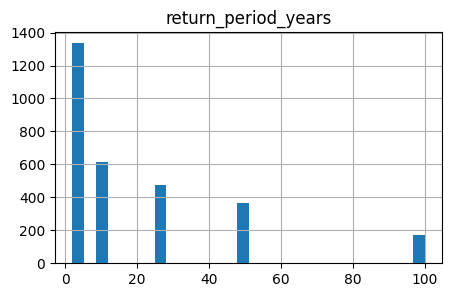

In [11]:
for col in numeric_features:
    plt.figure(figsize=(5,3))
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

##3.3 Categorical Variable Distribution

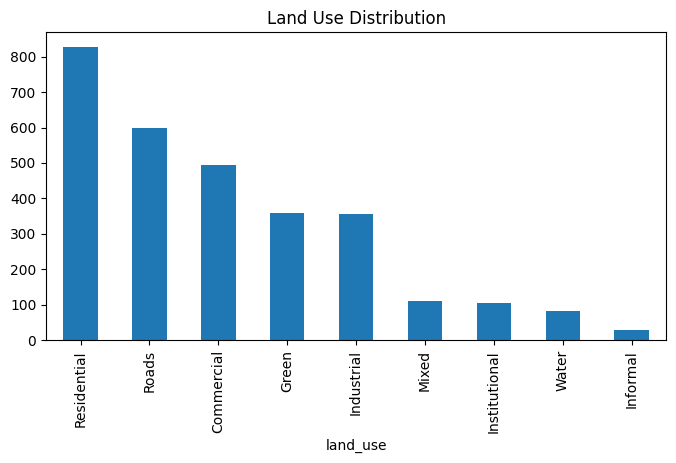

In [12]:
#Land Use
plt.figure(figsize=(8,4))

df["land_use"].value_counts().plot(kind="bar")

plt.title("Land Use Distribution")
plt.show()

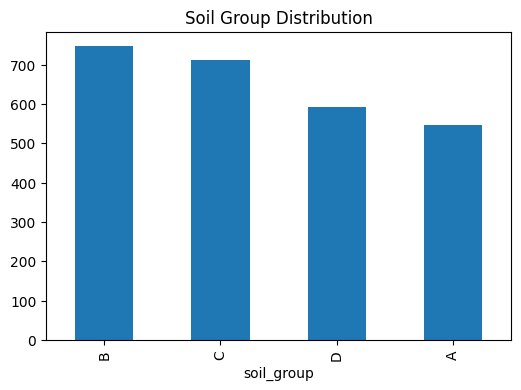

In [13]:
#Soil Group
plt.figure(figsize=(6,4))

df["soil_group"].value_counts().plot(kind="bar")

plt.title("Soil Group Distribution")
plt.show()

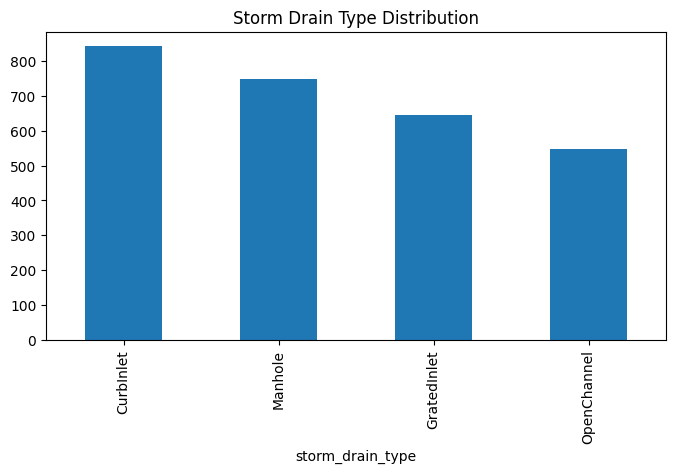

In [14]:
#Storm Drain Type

plt.figure(figsize=(8,4))

df["storm_drain_type"].value_counts().plot(kind="bar")

plt.title("Storm Drain Type Distribution")
plt.show()

##3.4 Flood Risk vs Numerical Variables

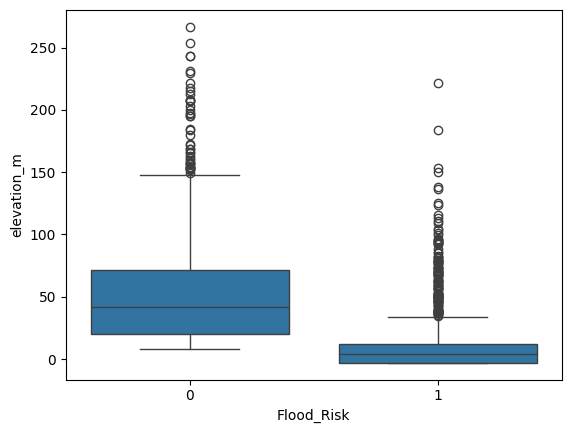

In [51]:
#Elevation

sns.boxplot(
    x="Flood_Risk",
    y="elevation_m",
    data=df
)

plt.show()

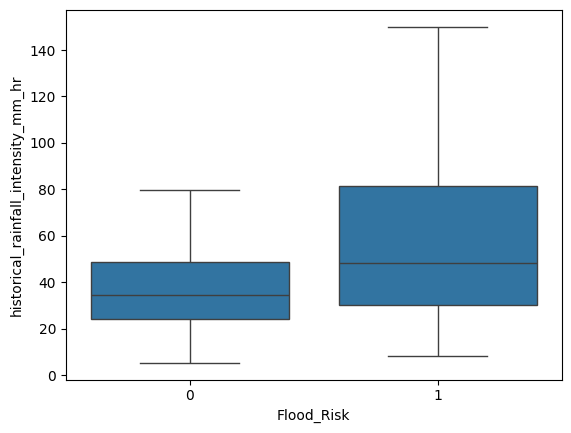

In [52]:
#Rainfall Intensity

sns.boxplot(
    x="Flood_Risk",
    y="historical_rainfall_intensity_mm_hr",
    data=df
)

plt.show()

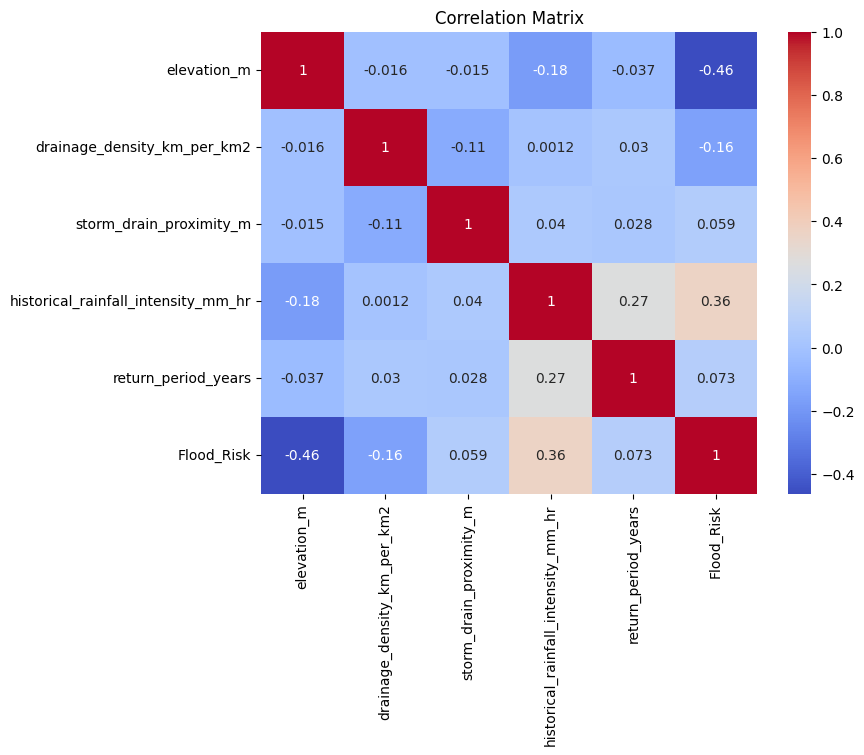

In [53]:
#Correlation Matrix

corr_features = [
    "elevation_m",
    "drainage_density_km_per_km2",
    "storm_drain_proximity_m",
    "historical_rainfall_intensity_mm_hr",
    "return_period_years",
    "Flood_Risk"
]

corr = df[corr_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# 4. Missing Value Analysis

In [20]:
df.isnull().sum().sort_values(ascending=False)

,0
soil_group,362
rainfall_source,315
drainage_density_km_per_km2,284
storm_drain_proximity_m,239
storm_drain_type,178
elevation_m,161
segment_id,0
latitude,0
city_name,0
land_use,0


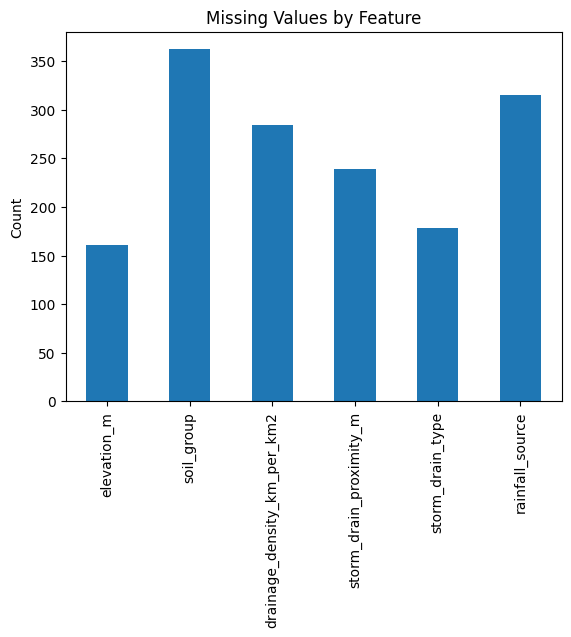

In [21]:
missing = df.isnull().sum()

missing[missing > 0].plot(kind="bar")

plt.title("Missing Values by Feature")
plt.ylabel("Count")
plt.show()

# 5. Target Variable Creation

The original dataset contains multiple flood-related risk labels. For classification purposes, a binary target variable was created:

- 0 = No Risk (monitor)
- 1 = Flood Risk

In [22]:
df["Flood_Risk"] = df["risk_labels"].apply(
    lambda x: 0 if x == "monitor" else 1
)

df["Flood_Risk"].value_counts()

,count
Flood_Risk,
0,1991
1,972


In [23]:
df["Flood_Risk"] = df["risk_labels"].apply(
    lambda x: 0 if x == "monitor" else 1
)

df["Flood_Risk"].value_counts()

,count
Flood_Risk,
0,1991
1,972


# 6. Data Preprocessing

## 6.1 Remove Unnecessary Features

Several identifier and location-related variables were removed because they do not directly contribute to flood risk prediction and may reduce model generalization.

In [24]:
df_model = df.drop(
    columns=[
        "segment_id",
        "city_name",
        "admin_ward",
        "catchment_id",
        "risk_labels",
        "latitude",
        "longitude"
    ]
)

df_model.head()

,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,Flood_Risk
0,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,0
1,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,1
2,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,0
3,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,0
4,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,0


##6.2 Missing Value Handling

In [25]:
df_model.isnull().sum()

,0
elevation_m,161
dem_source,0
land_use,0
soil_group,362
drainage_density_km_per_km2,284
storm_drain_proximity_m,239
storm_drain_type,178
rainfall_source,315
historical_rainfall_intensity_mm_hr,0
return_period_years,0


In [26]:
# Numerical columns
num_cols = df_model.select_dtypes(
    include=["int64", "float64"]
).columns

for col in num_cols:
    df_model[col] = df_model[col].fillna(
        df_model[col].median()
    )

# Categorical columns
cat_cols = df_model.select_dtypes(
    include=["object"]
).columns

for col in cat_cols:
    df_model[col] = df_model[col].fillna(
        df_model[col].mode()[0]
    )

df_model.isnull().sum()

,0
elevation_m,0
dem_source,0
land_use,0
soil_group,0
drainage_density_km_per_km2,0
storm_drain_proximity_m,0
storm_drain_type,0
rainfall_source,0
historical_rainfall_intensity_mm_hr,0
return_period_years,0


## 6.3 Encoding Categorical Variables

Categorical variables were transformed into numerical representations using one-hot encoding.

In [27]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

print(df_model.shape)

(2963, 27)


## 6.4 Feature and Target Separation

In [28]:
X = df_model.drop("Flood_Risk", axis=1)
y = df_model["Flood_Risk"]

print(X.shape)
print(y.shape)

(2963, 26)
(2963,)


## 6.5 Train-Test Split

The dataset was divided into training (80%) and testing (20%) subsets.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2370, 26)
(593, 26)


# 7. Classification Models


## 7.1 Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)
prec_dt = precision_score(y_test, pred_dt)
rec_dt = recall_score(y_test, pred_dt)
f1_dt = f1_score(y_test, pred_dt)

print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.9898819561551433
Precision: 0.9796954314720813
Recall   : 0.9897435897435898
F1 Score : 0.9846938775510204


#7.2 KNN

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)
prec_knn = precision_score(y_test, pred_knn)
rec_knn = recall_score(y_test, pred_knn)
f1_knn = f1_score(y_test, pred_knn)

print("Accuracy :", acc_knn)
print("Precision:", prec_knn)
print("Recall   :", rec_knn)
print("F1 Score :", f1_knn)

Accuracy : 0.8617200674536256
Precision: 0.8121546961325967
Recall   : 0.7538461538461538
F1 Score : 0.7819148936170213


##7.3 Logistic Resression

In [33]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
prec_lr = precision_score(y_test, pred_lr)
rec_lr = recall_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr)

print("Accuracy :", acc_lr)
print("Precision:", prec_lr)
print("Recall   :", rec_lr)
print("F1 Score :", f1_lr)

Accuracy : 0.7824620573355818
Precision: 0.6527777777777778
Recall   : 0.7230769230769231
F1 Score : 0.6861313868613139


## 7.4 Random Forest

In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
prec_rf = precision_score(y_test, pred_rf)
rec_rf = recall_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)

print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.9932546374367622
Precision: 0.9847715736040609
Recall   : 0.9948717948717949
F1 Score : 0.9897959183673469


In [35]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        acc_dt,
        acc_knn,
        acc_lr,
        acc_rf
    ],
    "Precision": [
        prec_dt,
        prec_knn,
        prec_lr,
        prec_rf
    ],
    "Recall": [
        rec_dt,
        rec_knn,
        rec_lr,
        rec_rf
    ],
    "F1 Score": [
        f1_dt,
        f1_knn,
        f1_lr,
        f1_rf
    ]
})

results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.993255,0.984772,0.994872,0.989796
0,Decision Tree,0.989882,0.979695,0.989744,0.984694
1,KNN,0.861720,0.812155,0.753846,0.781915
2,Logistic Regression,0.782462,0.652778,0.723077,0.686131


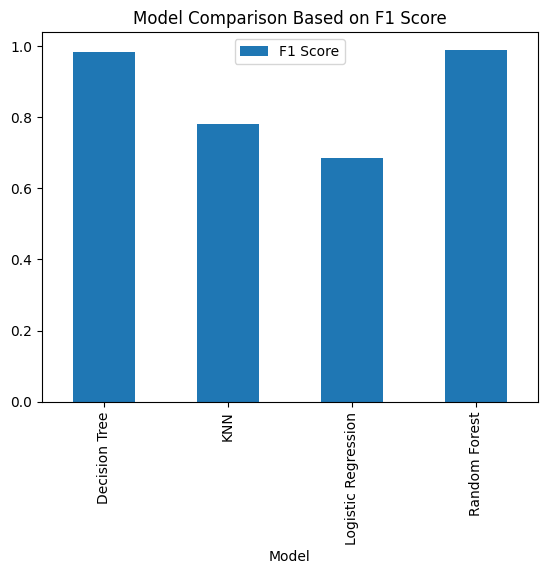

In [64]:
results.plot(
    x="Model",
    y="F1 Score",
    kind="bar"
)

plt.title("Model Comparison Based on F1 Score")
plt.show()

#9. Feature Importance, Cross Validation, Confusion Matrix

##9.1 Feature Importance

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(5)

,Feature,Importance
0,elevation_m,0.569473
3,historical_rainfall_intensity_mm_hr,0.191941
1,drainage_density_km_per_km2,0.145668
2,storm_drain_proximity_m,0.026477
4,return_period_years,0.014411


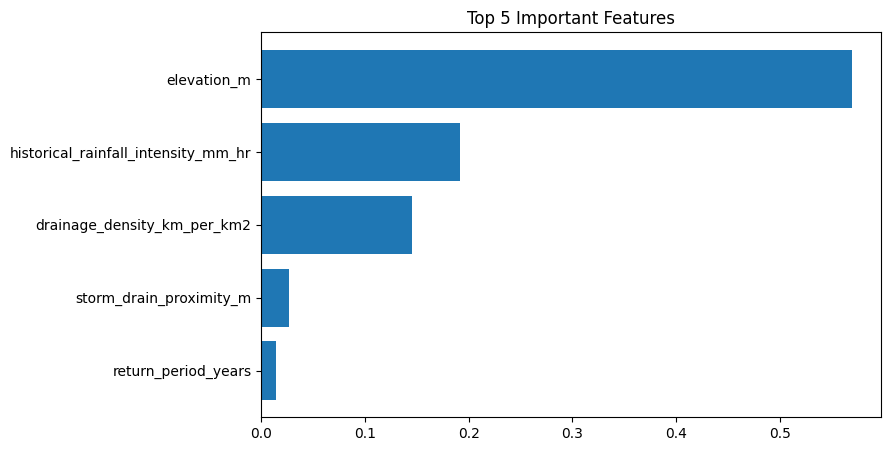

In [39]:
top5= feature_importance.head(5)

plt.figure(figsize=(8,5))

plt.barh(
    top5["Feature"],
    top5["Importance"]
)

plt.title("Top 5 Important Features")
plt.gca().invert_yaxis()

plt.show()

## 9.2 Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=10,
    scoring="f1"
)

print(scores.mean())
print(scores.std())

0.9964047795283918
0.003994114875807561


## 9.3 Confusion Matrix

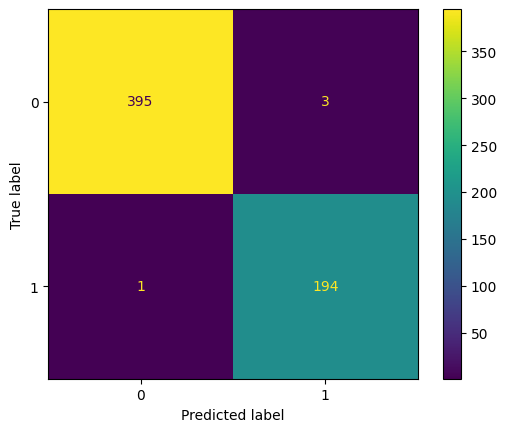

In [42]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf
)

plt.show()

# 10. Sensitivity Analysis

To better understand the influence of key variables, additional experiments were conducted.

Three scenarios were evaluated:

1. Full model using all features
2. Model using only the three most important features
3. Model excluding elevation, the most important feature

##10.1 Experiment 1 — Full Model

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Full Model Results")
print("------------------")
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

Full Model Results
------------------
Accuracy : 0.9932546374367622
Precision: 0.9847715736040609
Recall   : 0.9948717948717949
F1 Score : 0.9897959183673469


## 10.2 Experiment 2 — Top 3 Features Only

In [48]:
top3_features = [
    "elevation_m",
    "historical_rainfall_intensity_mm_hr",
    "drainage_density_km_per_km2"
]

X_top3 = df_model[top3_features]

y = df_model["Flood_Risk"]

X_train_t3, X_test_t3, y_train_t3, y_test_t3 = train_test_split(
    X_top3,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_top3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_top3.fit(X_train_t3, y_train_t3)

pred_top3 = rf_top3.predict(X_test_t3)

from sklearn.metrics import accuracy_score, f1_score

acc_top3 = accuracy_score(y_test_t3, pred_top3)
f1_top3 = f1_score(y_test_t3, pred_top3)

print("Accuracy:", acc_top3)
print("F1 Score:", f1_top3)

Accuracy: 0.9949409780775716
F1 Score: 0.9923273657289002


##10.3 Experiment 3 — Without Elevation

In [49]:
X_no_elev = X.drop(
    columns=["elevation_m"]
)

X_train_ne, X_test_ne, y_train_ne, y_test_ne = train_test_split(
    X_no_elev,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_no_elev = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_no_elev.fit(
    X_train_ne,
    y_train_ne
)

pred_no_elev = rf_no_elev.predict(
    X_test_ne
)

acc_no_elev = accuracy_score(
    y_test_ne,
    pred_no_elev
)

f1_no_elev = f1_score(
    y_test_ne,
    pred_no_elev
)

print("Accuracy:", acc_no_elev)
print("F1 Score:", f1_no_elev)

Accuracy: 0.7925801011804384
F1 Score: 0.5743944636678201


##10.4. Comparison Table

In [57]:
prec_rf = precision_score(y_test, pred_rf)
rec_rf = recall_score(y_test, pred_rf)

prec_top3 = precision_score(y_test_t3, pred_top3)
rec_top3 = recall_score(y_test_t3, pred_top3)

prec_no_elev = precision_score(y_test_ne, pred_no_elev)
rec_no_elev = recall_score(y_test_ne, pred_no_elev)

sensitivity_results = pd.DataFrame({
    "Scenario": [
        "Full Model",
        "Top 3 Features",
        "Without Elevation"
    ],
    "Accuracy": [
        acc_rf,
        acc_top3,
        acc_no_elev
    ],
    "Precision": [
        prec_rf,
        prec_top3,
        prec_no_elev
    ],
    "Recall": [
        rec_rf,
        rec_top3,
        rec_no_elev
    ],
    "F1 Score": [
        f1_rf,
        f1_top3,
        f1_no_elev
    ]
})

sensitivity_results

,Scenario,Accuracy,Precision,Recall,F1 Score
0,Full Model,0.993255,0.984772,0.994872,0.989796
1,Top 3 Features,0.994941,0.989796,0.994872,0.992327
2,Without Elevation,0.792580,0.882979,0.425641,0.574394


# 11. SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to interpret the predictions of the Random Forest model and understand the contribution of each feature to flood risk prediction.

In [58]:
!pip install shap -q

In [59]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

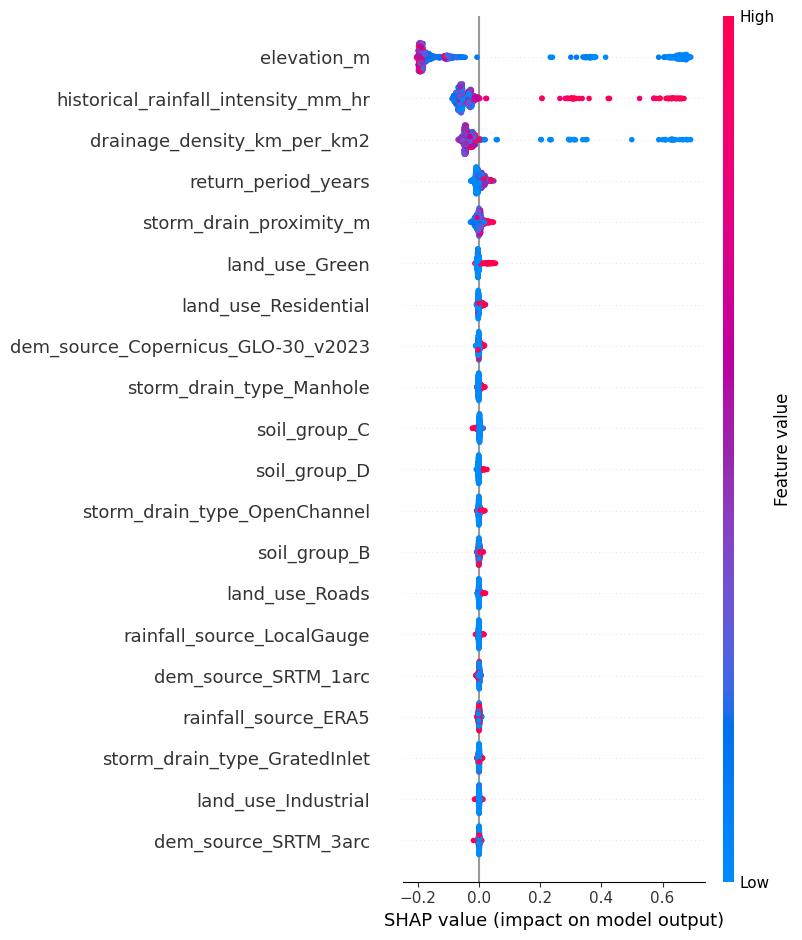

In [63]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)